# SUBSTATION CHANGE EVENT

**Description**: Substation Change in the Smart Grid Management system will represent a situation where there will be a mutation in the properties of a substation such as capacity_mw

**We shall use an ID registry, to enforce unique ID's to node and edges**

In [1]:
class IDRegistry:
    """Class to register IDs for various entities"""
    def __init__(self):
        self.used_ids = set()

    def register(self, id: str):
        if id in self.used_ids:
            raise ValueError(f"Duplicate ID detected: {id}")
        self.used_ids.add(id)
        return id

    def unregister(self, id: str):
        """Remove an ID from the registry"""
        self.used_ids.discard(id)  # discard won't raise an error if id is missing

    def __repr__(self):
        return f"IDRegistry(used_ids={list(self.used_ids)})"

## Creating Node Class

#### 🧩 Node — Grid Entity

#### Description

A `Node` represents a **physical component** of the electrical grid.  
Each node belongs to **exactly one grid** and has a **unique identity**.

Nodes are **structural entities**. They do not store time-dependent behavior or simulation results.

---

#### Supported Node Types

| Type | Description |
|-----|------------|
| `PLANT` | Power generation source (hydro, solar, thermal) |
| `SUBSTATION` | Transmission or distribution junction |
| `LOAD` | Electricity consumer |

---

#### Attributes

| Attribute | Type | Required | Description |
|---------|------|----------|------------|
| `id` | `str` | ✅ | Unique node identifier |
| `type` | `GridNodeType` | ✅ | Node category |
| `plant_type` | `str` | PLANT only | Energy source (hydro, solar, thermal) |
| `load_type` | `str` | LOAD only | Consumer category |
| `demand_mw` | `float` | LOAD only | Power demand in megawatts |
| `capacity_mw` | `float` | PLANT / SUBSTATION | Maximum generatable or transferable power |
| `priority` | `int` | Optional | Priority used during load shedding |

---

#### Validation Rules

- A `PLANT` must define `plant_type` and `capacity_mw`
- A `LOAD` must define `load_type` and `demand_mw`
- A `SUBSTATION` must define `capacity_mw`
- Invalid attribute combinations are rejected

---

#### Behavioral Notes

- Nodes do not store power flow
- Nodes do not store time
- Nodes do not know about events
- Nodes are immutable within a snapshot


In [2]:
from enum import Enum

class GridNodeType(str, Enum):
    PLANT = "PLANT"
    LOAD = "LOAD"
    SUBSTATION = "SUBSTATION"

class PlantType(str, Enum):
    HYDRO = "hydro"
    SOLAR = "solar"
    THERMAL = "thermal"


class LoadType(str, Enum):
    HOSPITAL = "hospital"
    ENTERPRISE = "enterprise"
    RESIDENTIAL = "residential"
    INDUSTRIAL = "industrial"


def validate_node_attributes(node_data: dict):
    """Function that is used to validate the node attributes"""
    node_type = node_data.get("type")

    if node_type == GridNodeType.PLANT:
        if not node_data.get("plant_type"):
            raise ValueError("Plant node must have 'plant_type' set.")

        if node_data.get("load_type") is not None or node_data.get("demand_mw") is not None:
            raise ValueError("Plant node cannot have load attributes.")

        if node_data.get("capacity_mw") is None:
            raise ValueError("Plant node must have 'capacity_mw' set.")

        if node_data.get("priority") is None:
            node_data["priority"] = 0

    elif node_type == GridNodeType.LOAD:
        if not node_data.get("load_type"):
            raise ValueError("Load node must have 'load_type' set.")

        if node_data.get("demand_mw") is None:
            raise ValueError("Load node must have 'demand_mw' set.")

        if node_data.get("plant_type") is not None or node_data.get("capacity_mw") is not None:
            raise ValueError("Load node cannot have plant or capacity attributes.")

        if node_data.get("priority") is None:
            node_data["priority"] = 0

    elif node_type == GridNodeType.SUBSTATION:
        if node_data.get("plant_type") is not None or node_data.get("load_type") is not None:
            raise ValueError("Substation node cannot have plant or load attributes.")

        if node_data.get("demand_mw") is not None:
            raise ValueError("Substation node cannot have demand_mw.")

        if node_data.get("capacity_mw") is None:
            raise ValueError("Substation node must have 'capacity_mw' set.")

    else:
        raise ValueError(f"Unknown node type: {node_type}")


In [3]:
class Node:
    def __init__(
        self,
        id: str,
        type: GridNodeType,
        plant_type: PlantType = None,
        load_type: LoadType = None,
        demand_mw=None,
        capacity_mw=None,
        priority=0,
    ):
        node_data = {
            "type": type,
            "plant_type": plant_type,
            "load_type": load_type,
            "demand_mw": demand_mw,
            "capacity_mw": capacity_mw,
            "priority": priority,
        }
        
        # convert string to Enum if needed
        if isinstance(node_data["type"], str):
            node_data["type"] = GridNodeType(node_data["type"])
        if node_data.get("plant_type") and isinstance(node_data["plant_type"], str):
            node_data["plant_type"] = PlantType(node_data["plant_type"])
        if node_data.get("load_type") and isinstance(node_data["load_type"], str):
            node_data["load_type"] = LoadType(node_data["load_type"])

        validate_node_attributes(node_data)

        self.id = id_registry.register(id)
        self.type = node_data["type"]
        self.plant_type = node_data["plant_type"]
        self.load_type = node_data["load_type"]
        self.demand_mw = node_data["demand_mw"]
        self.capacity_mw = node_data["capacity_mw"]
        self.priority = node_data["priority"]

    def __repr__(self):
        return (
            f"Node(id={self.id}, type={self.type}, plant_type={self.plant_type}, "
            f"load_type={self.load_type}, demand_mw={self.demand_mw}, "
            f"capacity_mw={self.capacity_mw}, priority={self.priority})"
        )

### Creating an Edge Class

#### 🔌 Edge — Transmission Line

#### Description

An `Edge` represents a **directed electrical transmission line** between two nodes.

Edges define **grid topology** and constrain how electricity flows through the grid.

---

#### Directionality

Edges are **directed**:


from_node ─────▶ to_node


Electricity may only flow in the declared direction.

---

#### Attributes

| Attribute | Type | Required | Description |
|---------|------|----------|------------|
| `id` | `str` | ✅ | Unique edge identifier |
| `from_node` | `Node.id` | ✅ | Source node |
| `to_node` | `Node.id` | ✅ | Target node |
| `capacity_mw` | `float` | ✅ | Maximum transferable power |
| `resistance` | `float` | Optional | Electrical resistance |
| `losses_percent` | `float` | Optional | Energy loss percentage (0–100) |
| `priority` | `int` | Optional | Used during overload resolution |
| `status` | `GridEdgeStatus` | Optional | `ACTIVE` or `OUTAGE` |

---

#### Validation Rules

- Self-loop edges are forbidden
- Parallel edges are forbidden
- Direction must respect node types:
  - `PLANT → SUBSTATION / LOAD`
  - `SUBSTATION → SUBSTATION / LOAD`
  - `LOAD → ❌`

---

#### Behavioral Notes

- Edge status may change during simulation
- Edges do not store power flow
- Power flow is always derived during simulation


In [4]:
from enum import Enum


class GridEdgeStatus(str, Enum):
    ACTIVE = "ACTIVE"
    DISABLED = "DISABLED"
    FAILED = "FAILED"


ALLOWED_FLOW = {
    "PLANT": {"SUBSTATION", "LOAD"},
    "SUBSTATION": {"SUBSTATION", "LOAD"},
    "LOAD": set(),
}


def validate_edge_attributes(edge_data: dict, from_node, to_node):
    # Self-loop
    if from_node.id == to_node.id:
        raise ValueError("Self-loop edges are not allowed")

    # Direction validation
    allowed_targets = ALLOWED_FLOW.get(from_node.type.value)
    if allowed_targets is None:
        raise ValueError(f"Unsupported from_node type: {from_node.type}")

    if to_node.type.value not in allowed_targets:
        raise ValueError(
            f"Invalid power flow: {from_node.type.value} → {to_node.type.value}"
        )

    # Capacity
    if edge_data.get("capacity_mw") is None or edge_data["capacity_mw"] <= 0:
        raise ValueError("Edge must have positive capacity_mw")

    # Losses
    losses = edge_data.get("losses_percent")
    if losses is not None and not (0 <= losses <= 100):
        raise ValueError("losses_percent must be between 0 and 100")


In [5]:
class Edge:
    def __init__(
        self,
        id: str,
        from_node: Node,
        to_node: Node,
        capacity_mw: float,
        resistance: float = None,
        losses_percent: float = None,
        priority: int = 0,
        status: GridEdgeStatus = GridEdgeStatus.ACTIVE,
    ):
        edge_data = {
            "capacity_mw": capacity_mw,
            "losses_percent": losses_percent,
        }

        if status and isinstance(status, str):
            status = GridEdgeStatus(status)
            
        validate_edge_attributes(edge_data, from_node, to_node)

        self.id = id_registry.register(id)
        self.from_node = from_node.id
        self.to_node = to_node.id
        self.capacity_mw = capacity_mw
        self.resistance = resistance
        self.losses_percent = losses_percent
        self.priority = priority
        self.status = status

    def __repr__(self):
            return (
                f"Edge(id={self.id}, from_node={self.from_node}, to_node={self.to_node}, "
                f"capacity_mw={self.capacity_mw}, resistance={self.resistance}, "
                f"losses_percent={self.losses_percent}, priority={self.priority}, "
                f"status={self.status})"
            )

## Directed Acyclic Graph (DAG)

### Purpose

The **Directed Acyclic Graph (DAG)** represents the electrical grid topology at a given snapshot in time.  
It models **nodes** (plants, substations, loads) and **directed edges** (power flow connections) while enforcing a **no-cycle constraint** at the logical level.

The DAG is the core structure used for:
- Grid traversal
- Island detection
- Power flow propagation
- Event-driven simulation

---

### Core Characteristics

- **Directed**  
  All edges have a defined direction (`from_node → to_node`) representing power flow.

- **Acyclic by Design**  
  The graph is expected to remain cycle-free.  
  Cycle prevention and validation are handled by an external **edge validator**, not the DAG itself.

- **Topology-Only Responsibility**  
  The DAG stores and manages:
  - Node existence
  - Edge connectivity
  - Adjacency relationships  
  It does **not** perform domain validation or business rules.

---

### Data Representation

The DAG is implemented using **adjacency lists** with explicit edge objects.

- **Nodes**
  - Stored as a mapping: `node_id → Node`
  - Nodes are treated as immutable structural entities

- **Edges**
  - Stored as a mapping: `edge_id → Edge`
  - Edges are first-class objects with metadata (capacity, status, etc.)

- **Adjacency Lists**
  - `adj`: Outgoing edges (`node_id → [Edge]`)
  - `rev_adj`: Incoming edges (`node_id → [Edge]`)

This dual adjacency structure allows:
- Efficient forward traversal
- Efficient backward traversal
- Fast island detection

---

### Identity Management

- Node and Edge IDs are managed externally by an **IDRegistry**
- The DAG does not generate IDs
- On removal of nodes or edges, the DAG ensures:
  - Structural cleanup
  - ID deregistration via the shared registry

This separation prevents tight coupling and ensures global ID consistency.

---

### Supported Operations

- Add / remove nodes
- Add / remove edges
- Query outgoing and incoming edges
- Neighbor discovery
- Edge existence checks
- Island (connected component) detection
- Full node and edge iteration

---

### Design Principles

- **Single Responsibility**  
  The DAG handles structure, not validation or simulation logic.

- **Explicit Relationships**  
  Edges are objects, not implicit connections.

- **Event-Driven Friendly**  
  The structure supports incremental updates caused by grid events.

- **Simulation-Oriented**  
  Optimized for traversal and state propagation rather than CRUD usage.

---

### What the DAG Does NOT Do

- Does not validate edge legality
- Does not enforce business constraints
- Does not compute power flow
- Does not mutate node or edge state
- Does not manage IDs internally

All such responsibilities are delegated to specialized components.

---


In [6]:
# Initialize the shared ids registry 
id_registry = IDRegistry()

In [7]:
class DAG:
    def __init__(self):
        # Store nodes: id -> Node object
        self.nodes = {}
        # Store edges: id -> Edge object
        self.edges = {}
        # Outgoing edges adjacency: node_id -> list of Edge objects
        self.adj = {}
        # Incoming edges adjacency: node_id -> list of Edge objects
        self.rev_adj = {}

    # Add a node to the DAG
    def add_node(self, node: Node):
        if node.id in self.nodes:
            raise ValueError(f"Node with id {node.id} already exists.")
        self.nodes[node.id] = node
        self.adj[node.id] = []
        self.rev_adj[node.id] = []

    # Add an edge to the DAG
    def add_edge(self, edge: Edge):
        if edge.id in self.edges:
            raise ValueError(f"Edge with id {edge.id} already exists.")
        if edge.from_node not in self.nodes or edge.to_node not in self.nodes:
            raise ValueError("Both nodes must exist in the DAG.")
        self.edges[edge.id] = edge
        self.adj[edge.from_node].append(edge)
        self.rev_adj[edge.to_node].append(edge)

    def remove_edge(self, edge_id: str):
        if edge_id not in self.edges:
            raise ValueError(f"Edge {edge_id} does not exist.")
        edge = self.edges[edge_id]
        # Remove from adjacency lists
        self.adj[edge.from_node] = [
            e for e in self.adj[edge.from_node] if e.id != edge_id
        ]
        self.rev_adj[edge.to_node] = [
            e for e in self.rev_adj[edge.to_node] if e.id != edge_id
        ]
        # Remove from edge registry
        del self.edges[edge_id]
        # IMPORTANT: free the ID
        id_registry.unregister(edge_id)

    def remove_node(self, node_id: str):
        if node_id not in self.nodes:
            raise ValueError(f"Node {node_id} does not exist.")
    
        # Remove all outgoing edges
        for edge in list(self.adj[node_id]):
            self.remove_edge(edge.id)
    
        # Remove all incoming edges
        for edge in list(self.rev_adj[node_id]):
            self.remove_edge(edge.id)

        # Remove node itself
        del self.nodes[node_id]
        del self.adj[node_id]
        del self.rev_adj[node_id]
        # IMPORTANT: free the ID
        id_registry.unregister(node_id)



    # Return all outgoing edges from a node
    def outgoing_edges(self, node_id: str):
        return self.adj.get(node_id, [])

    # Return all incoming edges to a node
    def incoming_edges(self, node_id: str):
        return self.rev_adj.get(node_id, [])

    # Return neighbor node IDs (destinations only)
    def neighbors(self, node_id: str):
        return [edge.to_node for edge in self.adj.get(node_id, [])]

    # Check if an edge exists between two nodes
    def has_edge(self, from_node: str, to_node: str):
        return any(edge.to_node == to_node for edge in self.adj.get(from_node, []))

    # Find all nodes connected to a start node (island detection)
    def find_island(self, start_node: str):
        visited = set()
        def dfs(node_id):
            if node_id in visited:
                return
            visited.add(node_id)
            # Traverse outgoing edges
            for edge in self.adj.get(node_id, []):
                if edge.status == GridEdgeStatus.ACTIVE:
                    dfs(edge.to_node)
            # Traverse incoming edges
            for edge in self.rev_adj.get(node_id, []):
                if edge.status == GridEdgeStatus.ACTIVE:
                    dfs(edge.from_node)
        dfs(start_node)
        return visited

    # Iterate over all nodes
    def all_nodes(self):
        return list(self.nodes.values())

    # Iterate over all edges
    def all_edges(self):
        return list(self.edges.values())

    def __repr__(self):
        return (
            f"DAG(nodes={list(self.nodes.keys())}, edges={list(self.edges.keys())}, "
            f"adj={{ {', '.join(f'{k}: {[e.to_node for e in v]}' for k,v in self.adj.items())} }})"
        )

#### CREATING A SMALL GRID

In [8]:
# -----------------------------
# Create a small grid
# -----------------------------
# Nodes
plant = Node("N1",type="PLANT", plant_type="hydro", capacity_mw=100)
substation = Node("N2", type="SUBSTATION", capacity_mw=80)
load1 = Node("N3", type="LOAD", load_type="hospital", demand_mw=50)
load2 = Node("N4", type="LOAD", load_type="industrial", demand_mw=30)

# DAG
dag = DAG()
for n in [plant, substation, load1, load2]:
    dag.add_node(n)

# Edges
e1 = Edge("e1", plant, substation, capacity_mw=80)
e2 = Edge("e2", substation, load1, capacity_mw=50)
e3 = Edge("e3", substation, load2, capacity_mw=40)

# Add edges to DAG
for e in [e1, e2, e3]:
    dag.add_edge(e)

# -----------------------------
# Display
# -----------------------------
print("Nodes:")
for n in [plant, substation, load1, load2]:
    print(n)

print("\nEdges:")
for e in [e1, e2, e3]:
    print(e)

print("\nDAG adjacency:")
print(dag)

Nodes:
Node(id=N1, type=GridNodeType.PLANT, plant_type=PlantType.HYDRO, load_type=None, demand_mw=None, capacity_mw=100, priority=0)
Node(id=N2, type=GridNodeType.SUBSTATION, plant_type=None, load_type=None, demand_mw=None, capacity_mw=80, priority=0)
Node(id=N3, type=GridNodeType.LOAD, plant_type=None, load_type=LoadType.HOSPITAL, demand_mw=50, capacity_mw=None, priority=0)
Node(id=N4, type=GridNodeType.LOAD, plant_type=None, load_type=LoadType.INDUSTRIAL, demand_mw=30, capacity_mw=None, priority=0)

Edges:
Edge(id=e1, from_node=N1, to_node=N2, capacity_mw=80, resistance=None, losses_percent=None, priority=0, status=GridEdgeStatus.ACTIVE)
Edge(id=e2, from_node=N2, to_node=N3, capacity_mw=50, resistance=None, losses_percent=None, priority=0, status=GridEdgeStatus.ACTIVE)
Edge(id=e3, from_node=N2, to_node=N4, capacity_mw=40, resistance=None, losses_percent=None, priority=0, status=GridEdgeStatus.ACTIVE)

DAG adjacency:
DAG(nodes=['N1', 'N2', 'N3', 'N4'], edges=['e1', 'e2', 'e3'], adj={ 

In [9]:
# Display the current variables present in memory
%whos

Variable                   Type          Data/Info
--------------------------------------------------
ALLOWED_FLOW               dict          n=3
DAG                        type          <class '__main__.DAG'>
Edge                       type          <class '__main__.Edge'>
Enum                       EnumType      <enum 'Enum'>
GridEdgeStatus             EnumType      <enum 'GridEdgeStatus'>
GridNodeType               EnumType      <enum 'GridNodeType'>
IDRegistry                 type          <class '__main__.IDRegistry'>
LoadType                   EnumType      <enum 'LoadType'>
Node                       type          <class '__main__.Node'>
PlantType                  EnumType      <enum 'PlantType'>
dag                        DAG           DAG(nodes=['N1', 'N2', 'N<...> 'N4'], N3: [], N4: [] })
e                          Edge          Edge(id=e3, from_node=N2,<...>us=GridEdgeStatus.ACTIVE)
e1                         Edge          Edge(id=e1, from_node=N1,<...>us=GridEdgeStatus.ACT

## GridSnapshot

Represents a snapshot of the power grid at a specific moment, used for simulations. It stores the grid's nodes, edges, and metadata, and can generate a DAG representation for algorithmic processing.

---

### Properties

- **nodes** `(List[Node])`  
  List of all `Node` objects in the grid snapshot. These are the entities that produce, consume, or transmit electricity.

- **edges** `(List[Edge])`  
  List of all `Edge` objects connecting nodes. Each edge contains metadata such as capacity, resistance, losses, priority, and status.

- **metadata** `(dict)`  
  Grid-level metadata, obligatory even if not used directly in simulations. Example:
  ```python
  {
      "base_power_mva": 100.0,
      "voltage_level": "110kV"
  }


In [10]:
from typing import List

class GridSnapshot:
    """
    Represents a snapshot of the grid for simulation purposes.
    
    Attributes:
        nodes (List[Node]): List of Node objects in the grid.
        edges (List[Edge]): List of Edge objects representing connections.
        metadata (dict): Grid-level metadata. Obligatory.
            Example:
            {
                "base_power_mva": 100.0,
                "voltage_level": "110kV"
            }
    """

    def __init__(self, nodes: List['Node'], edges: List['Edge'], metadata: dict):
        if not metadata:
            raise ValueError("metadata must be provided for GridSnapshot.")
        if not isinstance(nodes, list):
            raise TypeError("nodes must be a list of Node objects.")
        if not isinstance(edges, list):
            raise TypeError("edges must be a list of Edge objects.")
        
        self.nodes = nodes
        self.edges = edges
        self.metadata = metadata

    def get_node_by_id(self, node_id: str):
        """Retrieve a node object by its ID."""
        for node in self.nodes:
            if node.id == node_id:
                return node
        return None

    def get_edge_by_id(self, edge_id: str):
        """Retrieve an edge object by its ID."""
        for edge in self.edges:
            if edge.id == edge_id:
                return edge
        return None

    def to_dag(self) -> 'DAG':
        """
        Convert the grid snapshot into a DAG instance.
        
        Returns:
            DAG: A DAG populated with nodes and edges from the snapshot.
        """
        dag = DAG()
        
        # Add all nodes
        for node in self.nodes:
            dag.add_node(node)
        
        # Add all edges
        for edge in self.edges:
            dag.add_edge(edge)
        
        return dag

    def __repr__(self):
        return (
            f"GridSnapshot(nodes={[n.id for n in self.nodes]}, "
            f"edges={[e.id for e in self.edges]}, metadata={self.metadata})"
        )


In [11]:
# Create an example grid snapshot
snapshot = GridSnapshot(
    nodes=[plant, substation, load1, load2],
    edges=[e1, e2, e3],
    metadata={"base_power_mva": 100, "voltage_level": "110kV"}
)

# Convert to DAG
dag_ex = snapshot.to_dag()

# Inspect DAG
print(dag_ex)

DAG(nodes=['N1', 'N2', 'N3', 'N4'], edges=['e1', 'e2', 'e3'], adj={ N1: ['N2'], N2: ['N3', 'N4'], N3: [], N4: [] })


## SUBSTATION_CAPACITY_CHANGE Event

### Mutation Step

#### Purpose

Apply a `SUBSTATION_CAPACITY_CHANGE` event to a substation node in the grid DAG.  
This step performs the **direct mutation** of the substation's capacity, validates basic constraints, and identifies the affected portion of the grid (island) for further simulation steps.

---

#### Inputs

- **dag** (`DAG`): The directed acyclic graph representing the current grid state.  
- **substation_id** (`str`): ID of the substation node where the capacity is changing.  
- **new_capacity_mw** (`float`): The new capacity in MW to apply to the substation.

---

#### Outputs

- **affected_island** (`set[str]`): Set of node IDs connected to the changed substation, forming the affected island.  
- **violations** (`list[str]`): List of any immediate invariant violations detected during the mutation (e.g., negative capacity).

---

#### Algorithm (Steps)

1. **Retrieve substation**
    - Find the substation object in `dag.nodes` using `substation_id`.
    - Raise error if node is not found.

2. **Apply mutation**
    - Update `substation.capacity_mw` to `new_capacity_mw`.

3. **Validate immediate invariants**
    - If `substation.capacity_mw < 0`, append `"INVALID_CAPACITY: capacity < 0"` to `violations` and set `substation.capacity_mw = 0`.

4. **Identify affected island**
    - Call `dag.find_island(substation_id)` to determine all nodes connected to the changed substation.
    - Return this set as `affected_island`.

---

#### Notes

- **Simplified model**: No `max_capacity_mw` is implemented, so capping is not needed.  
- **Load redistribution or edge flow recalculation** is **not part of this step**; it may be applied later during simulation.  
- This step is **deterministic** and **stateless**, producing the same outputs for the same inputs.

---

#### Example Usage

```python
affected_island, violations = apply_substation_capacity_change(
    dag, substation_id="S2", new_capacity_mw=120
)
print("Affected nodes:", affected_island)
print("Violations:", violations)


In [12]:
# -----------------------------
# Create a GridSnapshot
# -----------------------------

# Nodes
plant = Node(
    id="NP1",
    type=GridNodeType.PLANT,
    plant_type=PlantType.HYDRO,
    capacity_mw=120,
    priority=1
)

substation = Node(
    id="NS1",
    type=GridNodeType.SUBSTATION,
    capacity_mw=100,
    priority=1
)

load1 = Node(
    id="NL1",
    type=GridNodeType.LOAD,
    load_type=LoadType.HOSPITAL,
    demand_mw=50,
    priority=2
)

load2 = Node(
    id="NL2",
    type=GridNodeType.LOAD,
    load_type=LoadType.INDUSTRIAL,
    demand_mw=70,
    priority=1
)

load3 = Node(
    id="NL3",
    type=GridNodeType.LOAD,
    load_type=LoadType.RESIDENTIAL,
    demand_mw=30,
    priority=3
)

# Edges
e1 = Edge(
    id="E1",
    from_node=plant,
    to_node=substation,
    capacity_mw=100,
    resistance=0.02,
    losses_percent=1.5,
    priority=1
)

e2 = Edge(
    id="E2",
    from_node=substation,
    to_node=load1,
    capacity_mw=60,
    resistance=0.01,
    losses_percent=0.5,
    priority=1
)

e3 = Edge(
    id="E3",
    from_node=substation,
    to_node=load2,
    capacity_mw=80,
    resistance=0.015,
    losses_percent=0.8,
    priority=1
)

e4 = Edge(
    id="E4",
    from_node=substation,
    to_node=load3,
    capacity_mw=50,
    resistance=0.02,
    losses_percent=1.0,
    priority=2
)

# Grid metadata
metadata = {
    "base_power_mva": 100.0,
    "voltage_level": "110kV",
    "description": "Sample simulation grid"
}

# Create GridSnapshot
grid_snapshot = GridSnapshot(
    nodes=[plant, substation, load1, load2, load3],
    edges=[e1, e2, e3, e4],
    metadata=metadata
)

# Display Grid Snapshot
print(grid_snapshot)

# Implementting the graph for the snapshot
dag1 = grid_snapshot.to_dag()
print(dag1)


GridSnapshot(nodes=['NP1', 'NS1', 'NL1', 'NL2', 'NL3'], edges=['E1', 'E2', 'E3', 'E4'], metadata={'base_power_mva': 100.0, 'voltage_level': '110kV', 'description': 'Sample simulation grid'})
DAG(nodes=['NP1', 'NS1', 'NL1', 'NL2', 'NL3'], edges=['E1', 'E2', 'E3', 'E4'], adj={ NP1: ['NS1'], NS1: ['NL1', 'NL2', 'NL3'], NL1: [], NL2: [], NL3: [] })


In [13]:
def apply_substation_capacity_change(dag: DAG, substation_id: str, new_capacity_mw: float):
    """
    Apply a SUBSTATION_CAPACITY_CHANGE event on a substation node in the DAG.

    Returns:
        affected_island (set): IDs of all nodes connected to this substation
        violations (list): any detected immediate violations
    """
    violations = []

    substation = dag.nodes.get(substation_id)
    if substation is None:
        raise ValueError(f"Node {substation_id} not found in DAG")

    # Step 0: Ensure the node is a substation
    if substation.type != "SUBSTATION":
        raise TypeError(
            f"Node {substation_id} is not a SUBSTATION (type={substation.type.value})"
        )

    # Step 1: Apply mutation
    substation.capacity_mw = new_capacity_mw

    # Step 2: Validate immediate invariants
    if substation.capacity_mw < 0:
        violations.append("INVALID_CAPACITY: capacity < 0")
        substation.capacity_mw = 0

    # Step 3: Identify affected island (connected component)
    affected_island = dag.find_island(substation_id)

    return affected_island, violations


In [14]:
# applying a change in substation supply

affected_island, violations = apply_substation_capacity_change(dag1, 'NS1', 50)
print("Affected Island:", affected_island,"\n","Violations:", violations)

Affected Island: {'NS1', 'NL3', 'NP1', 'NL2', 'NL1'} 
 Violations: []


### Redistribution Process (Substation Capacity Change)

Redistribution reallocates available power after a **SUBSTATION_CAPACITY_CHANGE** event.  
The goal is to ensure that power flows through the affected island respect the **updated substation capacity**, while still honoring edge limits, plant generation limits, and load priorities.

This process does **not** modify topology. It operates purely on runtime state.

---

#### `redistribute_power(dag, affected_island)`

**Purpose:**  
Perform priority-based redistribution of power within the affected island after a **substation capacity mutation**.

This step evaluates whether the new substation capacity can still support downstream demand and adjusts allocations accordingly.

---

**Inputs:**  
- **`dag`**: The directed acyclic graph representing the grid.  
- **`affected_island`**: Set of node IDs connected to the changed substation (from `apply_substation_capacity_change`).

---

**Outputs:**  
- **`plant_remaining`**: Remaining generation capacity at each plant.  
- **`substation_remaining`**: Remaining throughput capacity at each substation.  
- **`load_remaining`**: Remaining unmet demand at each load.  
- **`violations`**: Loads that could not be fully supplied due to substation, edge, or plant constraints.

---

**Notes:**  
- Loads are processed in **priority order** (highest priority first).  
- Upstream supply paths are identified via `find_supply_paths`.  
- Power is allocated while respecting:
  - Plant generation limits  
  - **Updated substation capacity limits**  
  - Edge capacity and status  
- No mutation occurs to DAG structure during this step.

---

#### `find_supply_paths(dag, load_id)`

**Purpose:**  
Identify all active upstream supply paths from a load to plant nodes, traversing through substations.

---

**Inputs:**  
- **`dag`**: The grid DAG.  
- **`load_id`**: Target load node ID.

---

**Outputs:**  
- List of tuples `(path_nodes, path_edges)` representing valid supply paths.

---

**Notes:**  
- Uses DFS on reverse adjacency (`rev_adj`).  
- Traversal stops at **plant nodes**.  
- Paths are valid only if:
  - All edges are `ACTIVE`
  - Intermediate substations have remaining capacity  
- Provides multiple candidate paths for redistribution.

---

#### Runtime State Tracking

Redistribution maintains **temporary runtime state** dictionaries:

- **`plant_remaining`**: Remaining generation at plants  
- **`substation_remaining`**: Remaining throughput at substations (**critical for this event**)  
- **`edge_remaining`**: Remaining capacity along edges  
- **`load_remaining`**: Unmet demand at loads  

**Why:**  
- Prevents capacity over-allocation  
- Allows controlled, stepwise redistribution  
- Keeps the DAG structure immutable

---

#### Redistribution Logic (Substation Capacity Aware)

For each load in descending priority order:

1. **Locate upstream supply paths** using `find_supply_paths`.
2. **For each candidate path**, compute transferable power as:



In [15]:
def initialize_runtime_state(dag: DAG, affected_island: set):
    plant_remaining = {}
    substation_remaining = {}
    edge_remaining = {}
    load_remaining = {}
    
    for node_id in affected_island:
        node = dag.nodes[node_id]
        if node.type == GridNodeType.PLANT:
            plant_remaining[node_id] = node.capacity_mw
        elif node.type == GridNodeType.SUBSTATION:
            substation_remaining[node_id] = node.capacity_mw
        elif node.type == GridNodeType.LOAD:
            load_remaining[node_id] = node.demand_mw

    for edge in dag.all_edges():
        if edge.from_node in affected_island and edge.to_node in affected_island:
            edge_remaining[edge.id] = edge.capacity_mw

    return plant_remaining, substation_remaining, edge_remaining, load_remaining


In [16]:
def find_supply_paths(dag: DAG, load_id: str, substation_remaining: dict):
    """
    Find all active upstream paths from a load to plants,
    respecting remaining substation capacity.
    """
    paths = []

    def dfs(current_node, path_nodes, path_edges):
        node_obj = dag.nodes[current_node]

        if node_obj.type == GridNodeType.SUBSTATION:
            if substation_remaining.get(current_node, 0) <= 0:
                return  # Substation saturated → dead path

        if node_obj.type == GridNodeType.PLANT:
            paths.append((path_nodes + [current_node], path_edges))
            return

        for edge in dag.incoming_edges(current_node):
            if edge.status == GridEdgeStatus.ACTIVE:
                dfs(
                    edge.from_node,
                    path_nodes + [current_node],
                    path_edges + [edge.id]
                )

    dfs(load_id, [], [])
    return paths


In [17]:
def apply_power_along_path(
    path_nodes,
    path_edges,
    plant_remaining,
    substation_remaining,
    edge_remaining,
    load_remaining
):
    plant_node = path_nodes[-1]
    load_node = path_nodes[0]

    min_edge_capacity = (
        min(edge_remaining[eid] for eid in path_edges)
        if path_edges else float("inf")
    )

    min_substation_capacity = min(
        substation_remaining[nid]
        for nid in path_nodes
        if nid in substation_remaining
    ) if any(nid in substation_remaining for nid in path_nodes) else float("inf")

    transferable = min(
        plant_remaining[plant_node],
        load_remaining[load_node],
        min_edge_capacity,
        min_substation_capacity
    )

    if transferable <= 0:
        return 0

    plant_remaining[plant_node] -= transferable
    load_remaining[load_node] -= transferable

    for edge_id in path_edges:
        edge_remaining[edge_id] -= transferable

    for nid in path_nodes:
        if nid in substation_remaining:
            substation_remaining[nid] -= transferable

    return transferable


In [18]:
def redistribute_power(dag: DAG, affected_island: set):
    """
    Redistribution after SUBSTATION_CAPACITY_CHANGE.
    """
    plant_remaining, substation_remaining, edge_remaining, load_remaining = (
        initialize_runtime_state(dag, affected_island)
    )

    violations = []

    loads = [
        dag.nodes[nid]
        for nid in affected_island
        if dag.nodes[nid].type == GridNodeType.LOAD
    ]
    loads.sort(key=lambda x: -x.priority)

    for load in loads:
        while load_remaining[load.id] > 0:
            paths = find_supply_paths(dag, load.id, substation_remaining)

            if not paths:
                violations.append(
                    (load.id, "INSUFFICIENT_SUBSTATION_CAPACITY")
                )
                break

            transferred_total = 0

            for nodes_path, edges_path in paths:
                power = apply_power_along_path(
                    nodes_path,
                    edges_path,
                    plant_remaining,
                    substation_remaining,
                    edge_remaining,
                    load_remaining
                )
                transferred_total += power

                if load_remaining[load.id] <= 0:
                    break

            if transferred_total == 0:
                violations.append(
                    (load.id, "SUBSTATION_THROUGHPUT_EXCEEDED")
                )
                break

    return plant_remaining, load_remaining, violations


### Load Shedding Algorithm (Substation Capacity Change)

#### Purpose

The **Load Shedding Algorithm** is a corrective mechanism executed **after power redistribution** when a **substation capacity reduction** prevents the grid from supplying all downstream loads.

In this context, load shedding resolves **shared substation bottlenecks** by intentionally reducing or disconnecting lower-priority loads so that higher-priority loads remain supplied **within the new substation throughput limit**.

---

#### When Load Shedding Is Triggered

Load shedding is applied **only if**:

- Redistribution has completed after a **SUBSTATION_CAPACITY_CHANGE** event, and  
- One or more downstream loads still have **unmet demand**

Formally:
```text
∃ load ∈ affected_island such that load_remaining[load] > 0


In [19]:
# -----------------------------
# Load Shedding Algorithm
# (Substation Capacity Change)
# -----------------------------
def apply_load_shedding_after_substation_change(
    dag: DAG,
    affected_island: set,
    load_remaining: dict
):
    """
    Reduce load demands to restore feasibility after a SUBSTATION_CAPACITY_CHANGE.

    Shedding is applied only to downstream loads whose demand could not be
    satisfied due to substation throughput constraints.

    Returns:
        shedding_report (list of dicts)
    """
    shedding_report = []

    # Step 1: Identify unsatisfied loads (after redistribution)
    unsatisfied_loads = [
        dag.nodes[lid]
        for lid, remaining in load_remaining.items()
        if remaining > 0 and lid in affected_island
    ]

    # Step 2: Sort loads by priority (LOW priority shed first)
    unsatisfied_loads.sort(key=lambda x: x.priority)

    # Step 3: Apply shedding to relieve substation bottlenecks
    for load in unsatisfied_loads:
        remaining_unmet = load_remaining.get(load.id, 0)
        if remaining_unmet <= 0:
            continue

        original_demand = load.demand_mw

        # Shed only what is necessary (partial or full)
        shed_amount = min(original_demand, remaining_unmet)

        # Apply shedding (persistent mutation)
        load.demand_mw -= shed_amount
        load_remaining[load.id] -= shed_amount

        shedding_report.append({
            "load_id": load.id,
            "priority": load.priority,
            "shed_mw": shed_amount,
            "new_demand_mw": load.demand_mw,
            "reason": "SUBSTATION_CAPACITY_LIMIT_EXCEEDED",
        })

        # Stop early if all unmet demand has been eliminated
        if all(v <= 0 for v in load_remaining.values()):
            break

    return shedding_report


### Combined SUBSTATION_CAPACITY_CHANGE Event Handling Algorithm

#### Purpose

This algorithm defines the **full lifecycle** of a `SUBSTATION_CAPACITY_CHANGE` event in the smart grid simulation.

A SUBSTATION_CAPACITY_CHANGE does **not** end at mutating capacity.  
Because a substation acts as a **shared throughput bottleneck**, the grid must **react**, re-evaluate downstream feasibility, redistribute power, and—if necessary—apply **load shedding** to restore operational stability.

---

#### High-Level Flow

```text
SUBSTATION_CAPACITY_CHANGE
   ↓
State Mutation (Substation capacity update)
   ↓
Identify Affected Island (downstream of substation)
   ↓
Power Redistribution (capacity-aware)
   ↓
Is Grid Feasible?
   ├── Yes → Done
   └── No
        ↓
     Load Shedding (priority-based, downstream)
        ↓
   Power Redistribution (post-shedding)
        ↓
   Final Feasible State or Infeasible Grid


In [20]:
# -----------------------------
# Combined SUBSTATION_CAPACITY_CHANGE Event Handler
# -----------------------------
def handle_substation_capacity_change_event(
    dag: DAG,
    substation_id: str,
    new_capacity_mw: float
):
    """
    Full SUBSTATION_CAPACITY_CHANGE event handler:
    - Apply SUBSTATION_CAPACITY_CHANGE mutation
    - Redistribute power along the grid
    - Apply load shedding if redistribution leaves unmet downstream loads
    - Re-run redistribution after shedding

    Returns updated DAG and event report
    """
    event_report = {
        "event": "SUBSTATION_CAPACITY_CHANGE",
        "substation_id": substation_id,
        "new_capacity_mw": new_capacity_mw,
        "initial_violations": [],
        "redistribution_violations": [],
        "load_shedding": [],
        "final_unserved_loads": [],
        "status": "STABLE"
    }

    # -----------------------------
    # Step 1 — Mutation
    # -----------------------------
    affected_island, violations = apply_substation_capacity_change(
        dag=dag,
        substation_id=substation_id,
        new_capacity_mw=new_capacity_mw
    )
    event_report["initial_violations"] = violations

    # -----------------------------
    # Step 2 — Redistribution
    # -----------------------------
    plant_remaining, load_remaining, redistribution_violations = redistribute_power(
        dag=dag,
        affected_island=affected_island
    )
    event_report["redistribution_violations"] = redistribution_violations

    # -----------------------------
    # Step 3 — Check if corrective action is needed
    # -----------------------------
    if redistribution_violations:
        # Step 3a — Apply Load Shedding on downstream loads
        shedding_report = apply_load_shedding_after_substation_change(
            dag=dag,
            affected_island=affected_island,
            load_remaining=load_remaining
        )
        event_report["load_shedding"] = shedding_report

        # Step 3b — Re-run Redistribution after shedding
        _, final_load_remaining, final_violations = redistribute_power(
            dag=dag,
            affected_island=affected_island
        )

        if final_violations:
            event_report["status"] = "INFEASIBLE"
            event_report["final_unserved_loads"] = final_violations
        else:
            event_report["status"] = "STABLE"

    return dag, event_report


### TESTING 
#### Code

In [21]:
# -----------------------------
# Create Another GridSnapshot Example to test SUBSTATION CAPACITY CHANGE EVENT
# -----------------------------

# Nodes
plant2 = Node(
    id="NP2",
    type=GridNodeType.PLANT,
    plant_type=PlantType.SOLAR,
    capacity_mw=90,     
    priority=1
)

substation2 = Node(
    id="NS2",
    type=GridNodeType.SUBSTATION,
    capacity_mw=55,         
    priority=1
)

load4 = Node(
    id="NL4",
    type=GridNodeType.LOAD,
    load_type=LoadType.HOSPITAL,
    demand_mw=30,          
    priority=1
)

load5 = Node(
    id="NL5",
    type=GridNodeType.LOAD,
    load_type=LoadType.INDUSTRIAL,
    demand_mw=35,
    priority=2
)

load6 = Node(
    id="NL6",
    type=GridNodeType.LOAD,
    load_type=LoadType.RESIDENTIAL,
    demand_mw=25,
    priority=3
)


# Edges
e5 = Edge(
    id="E5",
    from_node=plant2,
    to_node=substation2,
    capacity_mw=80,        
    resistance=0.009,
    losses_percent=0.8,
    priority=1
)

e6 = Edge(
    id="E6",
    from_node=substation2,
    to_node=load4,
    capacity_mw=40,
    resistance=0.007,
    losses_percent=0.4,
    priority=1
)

e7 = Edge(
    id="E7",
    from_node=substation2,
    to_node=load5,
    capacity_mw=40,
    resistance=0.011,
    losses_percent=0.6,
    priority=1
)

e8 = Edge(
    id="E8",
    from_node=substation2,
    to_node=load6,
    capacity_mw=30,
    resistance=0.01,
    losses_percent=0.5,
    priority=2
)

# Grid metadata
metadata2 = {
    "base_power_mva": 50.0,
    "voltage_level": "33kV",
    "description": "Substation capacity reduction test snapshot"
}

# Create GridSnapshot
grid_snapshot2 = GridSnapshot(
    nodes=[plant2, substation2, load4, load5, load6],
    edges=[e5, e6, e7, e8],
    metadata=metadata2
)

# Display Grid Snapshot
print(grid_snapshot2)

# Convert snapshot to DAG
dag2 = grid_snapshot2.to_dag()
print(dag2)


GridSnapshot(nodes=['NP2', 'NS2', 'NL4', 'NL5', 'NL6'], edges=['E5', 'E6', 'E7', 'E8'], metadata={'base_power_mva': 50.0, 'voltage_level': '33kV', 'description': 'Substation capacity reduction test snapshot'})
DAG(nodes=['NP2', 'NS2', 'NL4', 'NL5', 'NL6'], edges=['E5', 'E6', 'E7', 'E8'], adj={ NP2: ['NS2'], NS2: ['NL4', 'NL5', 'NL6'], NL4: [], NL5: [], NL6: [] })


### Visualize Graph BEFORE EVENT 
#### Code

/tmp/ipykernel_288971/4070345316.py:56: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', width=2)


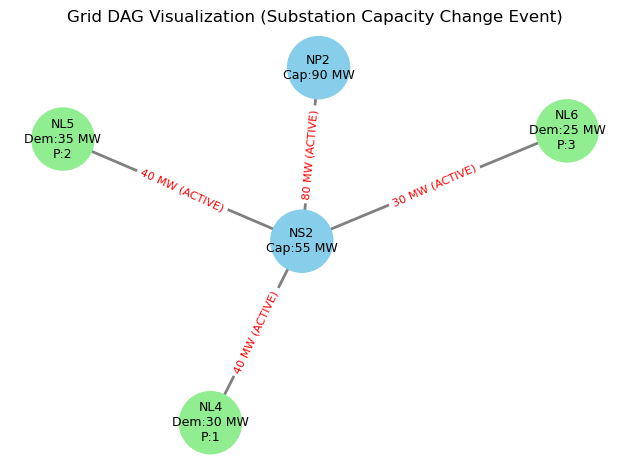

In [22]:
# -----------------------------
# Grid DAG Visualization (Substation Capacity Change Aware)
# -----------------------------
import networkx as nx
import matplotlib.pyplot as plt

def draw_grid_dag_substation_event(dag, affected_substations=None):
    """
    Draw a DAG of the grid with node info:
      - Plants/Substations: show capacity_mw (highlight affected substations)
      - Loads: show demand_mw and priority
      - Edges: show capacity_mw and status
    """
    if affected_substations is None:
        affected_substations = set()
    
    G = nx.DiGraph()
    
    # Add nodes
    for node_id, node in dag.nodes.items():
        G.add_node(node_id)
    
    # Add edges
    for edge in dag.all_edges():
        G.add_edge(edge.from_node, edge.to_node)
    
    # Node labels and colors
    labels = {}
    colors = []
    for node_id, node in dag.nodes.items():
        if node.type in (GridNodeType.PLANT, GridNodeType.SUBSTATION):
            label = f"{node_id}\nCap:{node.capacity_mw} MW"
            if node_id in affected_substations:
                label += " (UPDATED)"
                colors.append('orange')  # Highlight affected substation
            else:
                colors.append('skyblue')
            labels[node_id] = label
        elif node.type == GridNodeType.LOAD:
            labels[node_id] = f"{node_id}\nDem:{node.demand_mw} MW\nP:{node.priority}"
            colors.append('lightgreen')
        else:
            labels[node_id] = node_id
            colors.append('lightgray')
    
    # Layout
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except:
        pos = nx.spring_layout(G, seed=42, k=1.5)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=2000)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', width=2)
    
    # Node labels
    nx.draw_networkx_labels(G, pos, labels, font_size=9)
    
    # Edge labels
    edge_labels = {
        (e.from_node, e.to_node): f"{e.capacity_mw} MW ({e.status.name})"
        for e in dag.all_edges()
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)
    
    plt.title("Grid DAG Visualization (Substation Capacity Change Event)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# Example usage
draw_grid_dag_substation_event(dag2)


In [23]:
# Applying substation capacity change event 

final_grid, event_report = handle_substation_capacity_change_event(dag2, 'NS2', 70)

print("Final Grid", final_grid)
print("Event Report", event_report)

Final Grid DAG(nodes=['NP2', 'NS2', 'NL4', 'NL5', 'NL6'], edges=['E5', 'E6', 'E7', 'E8'], adj={ NP2: ['NS2'], NS2: ['NL4', 'NL5', 'NL6'], NL4: [], NL5: [], NL6: [] })
Event Report {'event': 'SUBSTATION_CAPACITY_CHANGE', 'substation_id': 'NS2', 'new_capacity_mw': 70, 'initial_violations': [], 'redistribution_violations': [('NL4', 'INSUFFICIENT_SUBSTATION_CAPACITY')], 'load_shedding': [{'load_id': 'NL4', 'priority': 1, 'shed_mw': 20, 'new_demand_mw': 10, 'reason': 'SUBSTATION_CAPACITY_LIMIT_EXCEEDED'}], 'final_unserved_loads': [], 'status': 'STABLE'}


### Visualize Graph AFTER EVENT
#### Code

/tmp/ipykernel_288971/4070345316.py:56: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', width=2)


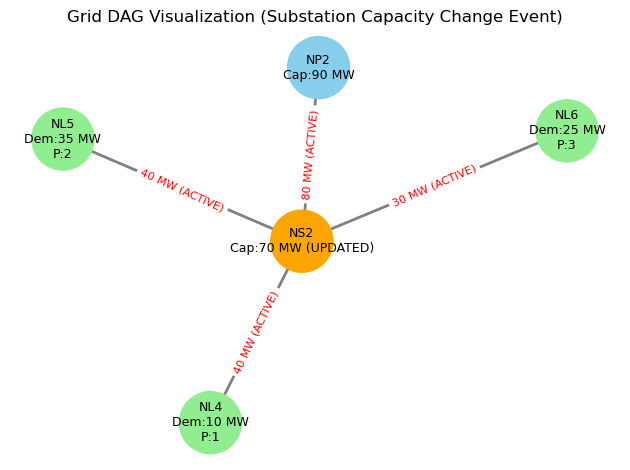

In [24]:
draw_grid_dag_substation_event(dag2, affected_substations={"NS2"})  # DAG object from GridSnapshot after event